In [48]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, date, timedelta
import seaborn as sns
import shapely

import plotting

In [49]:
gdf_track_info = gpd.read_parquet("../data/intermediate/track_info_unagg.parquet")
gdf_track_info.head(10)

,track_file,track_file_datetime,track_file_date,day_of_week,year,season,start_point,end_point,num_pauses,track_line,start_datetime,end_datetime,total_duration,active_duration,total_distance (mi),average_pace (min/mi),total_ascent (m),total_descent (m)
0,/Users/ryansponzilli/Developer/Python Projects...,2019-06-10 07:46:00-05:00,2019-06-10,Monday,Freshman,Summer Training,POINT (-88.32154 41.91101),POINT (-88.32166 41.9109),0,"MULTILINESTRING ((-88.32154 41.91101, -88.3215...",2019-06-10 11:57:42+00:00,2019-06-10 12:46:10+00:00,0 days 00:48:28,0 days 00:48:28,3.060933,8.542777,39.011887,-38.079392
1,/Users/ryansponzilli/Developer/Python Projects...,2019-06-11 07:32:00-05:00,2019-06-11,Tuesday,Freshman,Summer Training,POINT (-88.34764 41.928),POINT (-88.34792 41.92783),5,"MULTILINESTRING ((-88.34764 41.928, -88.34764 ...",2019-06-11 11:59:03+00:00,2019-06-11 12:32:23+00:00,0 days 00:33:20,0 days 00:33:10,3.154848,8.785222,60.890730,-61.285231
2,/Users/ryansponzilli/Developer/Python Projects...,2019-06-12 07:35:00-05:00,2019-06-12,Wednesday,Freshman,Summer Training,POINT (-88.32153 41.91251),POINT (-88.32172 41.911),5,"MULTILINESTRING ((-88.32153 41.91251, -88.3215...",2019-06-12 11:53:36+00:00,2019-06-12 12:35:13+00:00,0 days 00:41:43,0 days 00:30:46,2.521019,8.567542,68.381334,-63.546495
3,/Users/ryansponzilli/Developer/Python Projects...,2019-06-17 07:22:00-05:00,2019-06-17,Monday,Freshman,Summer Training,POINT (-88.32145 41.911),POINT (-88.32154 41.91096),0,"MULTILINESTRING ((-88.32145 41.911, -88.32143 ...",2019-06-17 11:52:32+00:00,2019-06-17 12:22:32+00:00,0 days 00:30:00,0 days 00:30:00,2.981428,9.099587,43.081880,-42.863923
4,/Users/ryansponzilli/Developer/Python Projects...,2019-06-18 07:19:00-05:00,2019-06-18,Tuesday,Freshman,Summer Training,POINT (-88.35416 41.92575),POINT (-88.34797 41.92783),3,"MULTILINESTRING ((-88.35416 41.92575, -88.3541...",2019-06-18 11:53:58+00:00,2019-06-18 12:19:21+00:00,0 days 00:25:23,0 days 00:25:03,2.343798,9.394596,49.200207,-46.531003
6,/Users/ryansponzilli/Developer/Python Projects...,2019-06-19 07:28:00-05:00,2019-06-19,Wednesday,Freshman,Summer Training,POINT (-88.30833 41.90543),POINT (-88.32177 41.91104),3,"MULTILINESTRING ((-88.30833 41.90543, -88.3083...",2019-06-19 12:00:14+00:00,2019-06-19 12:28:20+00:00,0 days 00:28:06,0 days 00:28:00,1.892663,9.153481,32.690991,-9.443326
7,/Users/ryansponzilli/Developer/Python Projects...,2019-06-20 07:21:00-05:00,2019-06-20,Thursday,Freshman,Summer Training,POINT (-88.30986 41.9092),POINT (-88.31042 41.90834),4,"MULTILINESTRING ((-88.30986 41.9092, -88.30985...",2019-06-20 11:41:38+00:00,2019-06-20 12:21:03+00:00,0 days 00:39:25,0 days 00:39:17,3.103609,9.793146,29.641343,-27.690675
8,/Users/ryansponzilli/Developer/Python Projects...,2019-06-20 19:20:00-05:00,2019-06-20,Thursday,Freshman,Summer Training,POINT (-88.28697 41.9046),POINT (-88.29997 41.91486),1,"MULTILINESTRING ((-88.28697 41.9046, -88.28698...",2019-06-21 00:00:35+00:00,2019-06-21 00:20:51+00:00,0 days 00:20:16,0 days 00:20:14,1.992385,9.128617,25.356718,-37.743681
9,/Users/ryansponzilli/Developer/Python Projects...,2019-06-20 19:32:00-05:00,2019-06-20,Thursday,Freshman,Summer Training,POINT (-88.29833 41.91238),POINT (-88.28806 41.90672),0,"MULTILINESTRING ((-88.29833 41.91238, -88.2983...",2019-06-21 00:24:35+00:00,2019-06-21 00:32:57+00:00,0 days 00:08:22,0 days 00:08:22,0.821639,9.433598,9.771438,-4.876861
10,/Users/ryansponzilli/Developer/Python Projects...,2019-06-24 07:33:00-05:00,2019-06-24,Monday,Freshman,Summer Training,POINT (-88.32007 41.90242),POINT (-88.32056 41.90151),11,"MULTILINESTRING ((-88.32007 41.90242, -88.3200...",2019-06-24 11:57:28+00:00,2019-06-24 12:33:03+00:00,0 days 00:34:38,0 days 00:34:16,2.629928,9.592020,55.898393,-37.104555


In [50]:
# isolate dates with multiple runs for further processing
counts = gdf_track_info[["track_file_date", "start_datetime"]].groupby("track_file_date").agg("count")
multple_dates = counts.loc[counts["start_datetime"] > 1].index
# dataframe with single-run dates
gdf_track_info_singles = gdf_track_info.loc[~gdf_track_info['track_file_date'].isin(multple_dates)]
# dataframe with multiple-run dates
gdf_track_info_multiples = gdf_track_info.loc[gdf_track_info['track_file_date'].isin(multple_dates)]

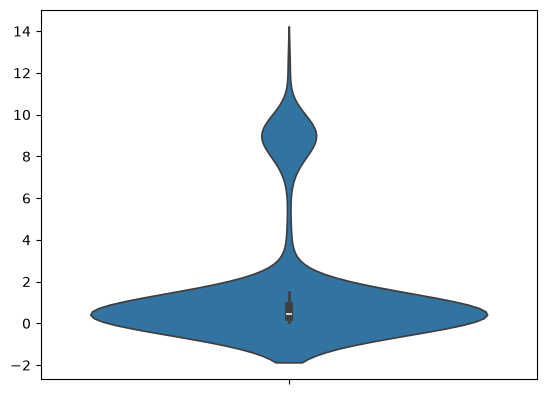

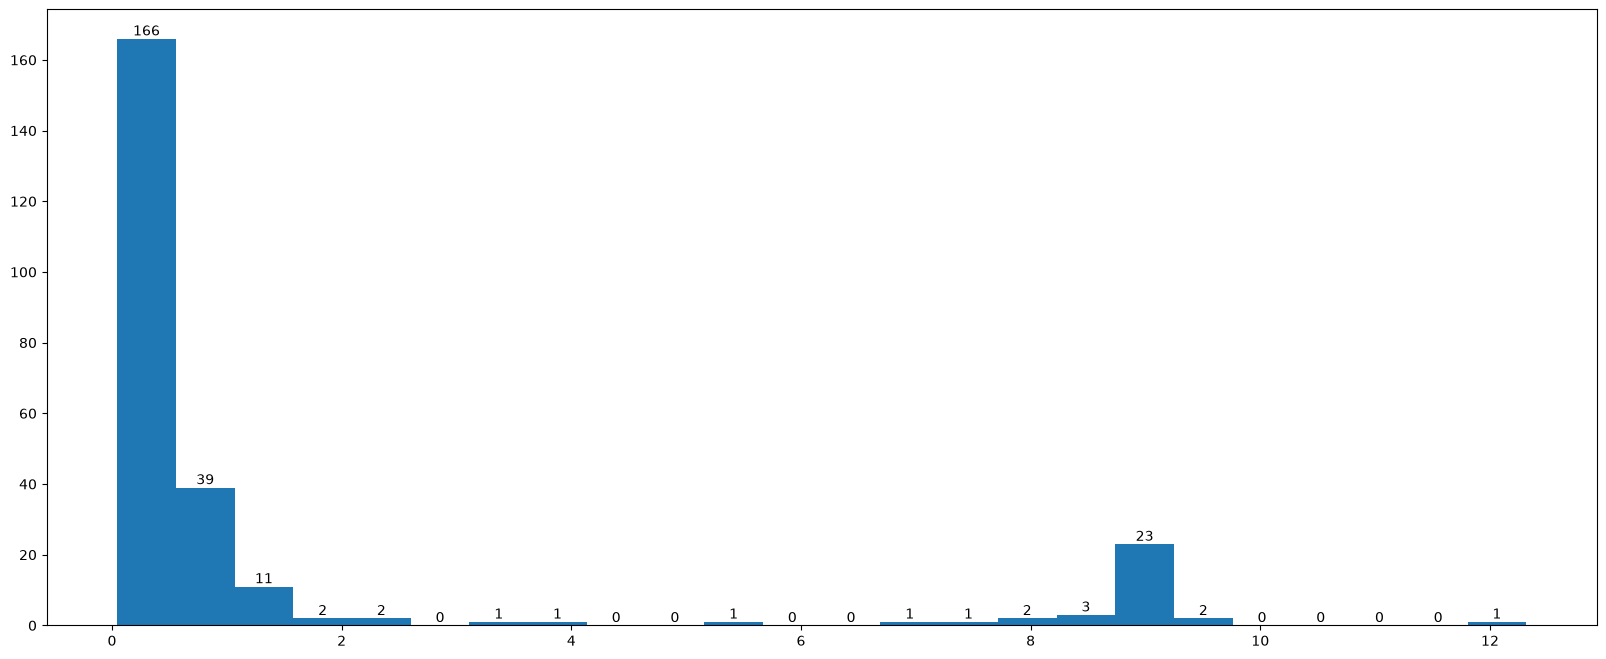

In [51]:
# plots exploring doubles
diff_list = []
for group_name, group in gdf_track_info_multiples.groupby("track_file_date"):
    diff_list += list(group["start_datetime"].diff().apply(lambda x: x.total_seconds()/60).values[1::])

diff_list = np.array(diff_list) / 60

sns.violinplot(diff_list)
plt.show()

plt.figure(figsize=(20, 8))

cts, bins, patches = plt.hist(diff_list, bins=24)

for c, left, right in zip(cts, bins[:-1], bins[1:]):
    center = (left + right) / 2
    plt.text(center, c, f'{int(c)}',
             ha='center', va='bottom')

plt.show()

Sometimes, I chose to record a workout all in the same recorded activity, and other times I broke it into several recorded activities. I need to standardize this. All workouts should be combined into one activity. Note that their statistics should be recomputed after being combined.

First, identify all dates with more than one recorded activity. Then take these and group them by date. Within each group, first determine if one of the runs is a double and keep it separate, and then combine the rest of the activities. This will combine both workouts and accidental splits together.

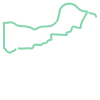

In [52]:
gdf_track_info.loc[gdf_track_info['track_file_datetime'] == pd.to_datetime("2021-09-01 15:59:00-05:00")].iloc[0]['track_line']

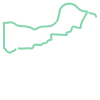

In [53]:
gdf_track_info.loc[gdf_track_info['track_file_datetime'] == pd.to_datetime("2021-09-01 15:59:00-05:00")].iloc[0]['track_line'].geoms[:]

In [54]:
def agg_track_lines(series):
    lines = []
    for mline in series:
        for line in mline.geoms:
            lines.append(line)
    return shapely.MultiLineString(lines)

rows = []
agg_dict = {
    "track_file": 'sum',
    "track_file_datetime": 'min',
    "day_of_week": 'first',
    "start_datetime": 'first',
    "end_datetime": 'last',
    "year": 'first',
    "season": 'first',
    "num_pauses": 'sum',
    "total_duration": 'sum',
    "active_duration": 'sum',
    "total_distance (mi)": 'sum',
    "average_pace (min/mi)": 'mean',
    "total_ascent (m)": 'sum',
    "total_descent (m)": 'sum',
    "start_point": 'first',
    "end_point": 'last',
    "track_line": agg_track_lines
}

for group_name, group in gdf_track_info_multiples.groupby("track_file_date"):
    split = group['start_datetime'].diff().apply(lambda x: x.total_seconds()/3600) > 3
    if split.sum() > 0:
        # add condensed first session
        temp = group[:split.argmax()].groupby("track_file_date").agg(agg_dict).reset_index()
        temp["num_pauses"] = temp["num_pauses"] + len(group[:split.argmax()]) - 1
        rows.append(temp)

        # add condensed second session
        temp = group[split.argmax():].groupby("track_file_date").agg(agg_dict).reset_index()
        temp["num_pauses"] = temp["num_pauses"] + len(group[split.argmax():]) - 1
        rows.append(temp)
    else:
        # add condensed session
        rows.append(group.groupby("track_file_date").agg(agg_dict).reset_index())

gdf_track_info_multiples_combined = gpd.GeoDataFrame(pd.concat(rows), geometry="track_line", crs="EPSG:4326")
gdf_track_info_multiples_combined["start_point"] = gpd.GeoSeries(gdf_track_info_multiples_combined["end_point"], crs=gdf_track_info_multiples_combined.crs)
gdf_track_info_multiples_combined["end_point"] = gpd.GeoSeries(gdf_track_info_multiples_combined["end_point"], crs=gdf_track_info_multiples_combined.crs)
gdf_track_info_multiples_combined

,track_file_date,track_file,track_file_datetime,day_of_week,start_datetime,end_datetime,year,season,num_pauses,total_duration,active_duration,total_distance (mi),average_pace (min/mi),total_ascent (m),total_descent (m),start_point,end_point,track_line
0,2019-06-20,/Users/ryansponzilli/Developer/Python Projects...,2019-06-20 07:21:00-05:00,Thursday,2019-06-20 11:41:38+00:00,2019-06-20 12:21:03+00:00,Freshman,Summer Training,4,0 days 00:39:25,0 days 00:39:17,3.103609,9.793146,29.641343,-27.690675,POINT (-88.31042 41.90834),POINT (-88.31042 41.90834),"MULTILINESTRING ((-88.30986 41.9092, -88.30985..."
0,2019-06-20,/Users/ryansponzilli/Developer/Python Projects...,2019-06-20 19:20:00-05:00,Thursday,2019-06-21 00:00:35+00:00,2019-06-21 00:32:57+00:00,Freshman,Summer Training,2,0 days 00:28:38,0 days 00:28:36,2.814023,9.281108,35.128156,-42.620542,POINT (-88.28806 41.90672),POINT (-88.28806 41.90672),"MULTILINESTRING ((-88.28697 41.9046, -88.28698..."
0,2019-06-26,/Users/ryansponzilli/Developer/Python Projects...,2019-06-26 07:11:00-05:00,Wednesday,2019-06-26 11:52:24+00:00,2019-06-26 13:01:36+00:00,Freshman,Summer Training,7,0 days 01:05:52,0 days 00:55:46,4.353060,9.419139,135.423601,-90.714006,POINT (-88.32042 41.90189),POINT (-88.32042 41.90189),"MULTILINESTRING ((-88.3199 41.90209, -88.3199 ..."
0,2019-07-17,/Users/ryansponzilli/Developer/Python Projects...,2019-07-17 06:59:00-05:00,Wednesday,2019-07-17 11:53:18+00:00,2019-07-17 12:34:28+00:00,Freshman,Summer Training,0,0 days 00:18:22,0 days 00:18:22,1.942416,8.910520,60.246660,-42.594987,POINT (-88.32055 41.90178),POINT (-88.32055 41.90178),"MULTILINESTRING ((-88.31905 41.90737, -88.3190..."
0,2019-07-25,/Users/ryansponzilli/Developer/Python Projects...,2019-07-25 06:52:00-05:00,Thursday,2019-07-25 11:44:12+00:00,2019-07-25 13:04:28+00:00,Freshman,Summer Training,1,0 days 00:16:34,0 days 00:15:46,1.761788,8.649105,15.534822,-13.028947,POINT (-88.27989 41.92837),POINT (-88.27989 41.92837),"MULTILINESTRING ((-88.27982 41.92933, -88.2798..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,2023-03-23,/Users/ryansponzilli/Developer/Python Projects...,2023-03-23 15:24:00-05:00,Thursday,2023-03-23 20:09:00+00:00,2023-03-23 21:37:05+00:00,Senior,Track Season,5,0 days 00:35:40,0 days 00:34:03,4.230535,7.914526,28.887637,-28.006312,POINT (-88.27992 41.92847),POINT (-88.27992 41.92847),"MULTILINESTRING ((-88.27981 41.92898, -88.2798..."
0,2023-04-03,/Users/ryansponzilli/Developer/Python Projects...,2023-04-03 15:19:00-05:00,Monday,2023-04-03 20:04:13+00:00,2023-04-03 21:09:03+00:00,Senior,Track Season,14,0 days 00:50:28,0 days 00:34:31,5.083424,6.365147,25.163069,-25.619814,POINT (-88.27734 41.92835),POINT (-88.27734 41.92835),"MULTILINESTRING ((-88.28006 41.92835, -88.2800..."
0,2023-04-05,/Users/ryansponzilli/Developer/Python Projects...,2023-04-05 15:07:00-05:00,Wednesday,2023-04-05 19:48:23+00:00,2023-04-05 20:53:00+00:00,Senior,Track Season,6,0 days 00:53:50,0 days 00:52:24,6.736766,7.713403,101.520549,-111.003257,POINT (-88.27995 41.92852),POINT (-88.27995 41.92852),"MULTILINESTRING ((-88.2798 41.92862, -88.2798 ..."
0,2023-04-14,/Users/ryansponzilli/Developer/Python Projects...,2023-04-14 16:03:00-05:00,Friday,2023-04-14 20:54:03+00:00,2023-04-14 22:52:38+00:00,Senior,Track Season,1,0 days 00:13:42,0 days 00:13:40,1.725337,7.936339,12.008362,-11.990151,POINT (-88.15881 41.78483),POINT (-88.15881 41.78483),"MULTILINESTRING ((-88.15822 41.78437, -88.1582..."


In [55]:
gdf_track_info = pd.concat([gdf_track_info_singles, gdf_track_info_multiples_combined]).sort_values("track_file_datetime").reset_index(drop=True)
gdf_track_info.head()

,track_file,track_file_datetime,track_file_date,day_of_week,year,season,start_point,end_point,num_pauses,track_line,start_datetime,end_datetime,total_duration,active_duration,total_distance (mi),average_pace (min/mi),total_ascent (m),total_descent (m)
0,/Users/ryansponzilli/Developer/Python Projects...,2019-06-10 07:46:00-05:00,2019-06-10,Monday,Freshman,Summer Training,POINT (-88.32154 41.91101),POINT (-88.32166 41.9109),0,"MULTILINESTRING ((-88.32154 41.91101, -88.3215...",2019-06-10 11:57:42+00:00,2019-06-10 12:46:10+00:00,0 days 00:48:28,0 days 00:48:28,3.060933,8.542777,39.011887,-38.079392
1,/Users/ryansponzilli/Developer/Python Projects...,2019-06-11 07:32:00-05:00,2019-06-11,Tuesday,Freshman,Summer Training,POINT (-88.34764 41.928),POINT (-88.34792 41.92783),5,"MULTILINESTRING ((-88.34764 41.928, -88.34764 ...",2019-06-11 11:59:03+00:00,2019-06-11 12:32:23+00:00,0 days 00:33:20,0 days 00:33:10,3.154848,8.785222,60.890730,-61.285231
2,/Users/ryansponzilli/Developer/Python Projects...,2019-06-12 07:35:00-05:00,2019-06-12,Wednesday,Freshman,Summer Training,POINT (-88.32153 41.91251),POINT (-88.32172 41.911),5,"MULTILINESTRING ((-88.32153 41.91251, -88.3215...",2019-06-12 11:53:36+00:00,2019-06-12 12:35:13+00:00,0 days 00:41:43,0 days 00:30:46,2.521019,8.567542,68.381334,-63.546495
3,/Users/ryansponzilli/Developer/Python Projects...,2019-06-17 07:22:00-05:00,2019-06-17,Monday,Freshman,Summer Training,POINT (-88.32145 41.911),POINT (-88.32154 41.91096),0,"MULTILINESTRING ((-88.32145 41.911, -88.32143 ...",2019-06-17 11:52:32+00:00,2019-06-17 12:22:32+00:00,0 days 00:30:00,0 days 00:30:00,2.981428,9.099587,43.081880,-42.863923
4,/Users/ryansponzilli/Developer/Python Projects...,2019-06-18 07:19:00-05:00,2019-06-18,Tuesday,Freshman,Summer Training,POINT (-88.35416 41.92575),POINT (-88.34797 41.92783),3,"MULTILINESTRING ((-88.35416 41.92575, -88.3541...",2019-06-18 11:53:58+00:00,2019-06-18 12:19:21+00:00,0 days 00:25:23,0 days 00:25:03,2.343798,9.394596,49.200207,-46.531003


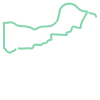

In [56]:
gdf_track_info.loc[gdf_track_info['track_file_datetime'] == pd.to_datetime("2021-09-01 15:59:00-05:00")].iloc[0]['track_line']